# Informe de Insights Competitivos — Rappi vs Uber Eats vs DiDi Food

**Fecha:** 2026-05-11 · **Autor:** Julieta Pages · **Reto:** Rappi AI Engineer

Análisis comparativo estructurado y Top 5 insights accionables sobre un muestreo controlado de **3 plataformas × 6 zonas CDMX/EdoMex × 5 SKUs estandarizados** (McDonald's + retail). Datos en `data/scrapes.csv`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/scrapes.csv")
av = df[df["available"]].copy()

PLATFORM_COLORS = {"rappi": "#FF441F", "ubereats": "#06C167", "didi": "#FF7900"}
print(f"Total filas: {len(df)} | Disponibles: {len(av)} | Plataformas: {df['platform'].nunique()}")
df.groupby("platform")["available"].agg(["sum", "count"])


Total filas: 90 | Disponibles: 33 | Plataformas: 3


,sum,count
platform,,
didi,0,30
rappi,16,30
ubereats,17,30


## Resumen ejecutivo

Muestreo de **90 observaciones** (3 plataformas × 6 zonas × 5 SKUs) tomadas en un único snapshot. **33 quedaron con datos completos**; el gap principal es DiDi Food (0 / 30) que no expone web pública en CDMX — únicamente app móvil con tráfico firmado. Los SKUs de retail (Coca-Cola 500ml, Agua 1L) no encontraron match en los menús de McDonald's, por lo que el análisis cuantitativo se restringe a los 3 SKUs de fast-food (Big Mac, McNuggets 10pz, Combo Big Mac mediano) en Rappi y Uber Eats.

**Cinco preguntas que responde este informe:**
1. **Precios** — ¿Rappi está más caro, más barato o similar?
2. **ETA** — ¿quién entrega más rápido y dónde?
3. **Fees** — ¿cómo se compone el ticket final entre plataformas?
4. **Promos** — ¿qué tipo de descuentos comunica cada una?
5. **Geografía** — ¿la competitividad cambia entre zonas?

Al final: **Top 5 insights accionables** con Finding / Impacto / Recomendación.

**Caveats honestos** (ver también `docs/blockers.md`):
- DiDi sin datos cuantitativos → solo análisis de *presencia*.
- Snapshot único; sin variabilidad temporal.
- Sin login real (usuario anónimo) → fees y promos representan la oferta de adquisición, no la de usuarios recurrentes.


## 1. Posicionamiento de precios

Precio unitario promedio del producto (sin fees ni descuentos) por SKU y plataforma. Solo `available==True`.


platform            rappi  ubereats
product_sku                        
Big Mac             130.7     130.7
Combo Big Mac med.  169.0     169.0
McNuggets 10pz      137.8     137.8


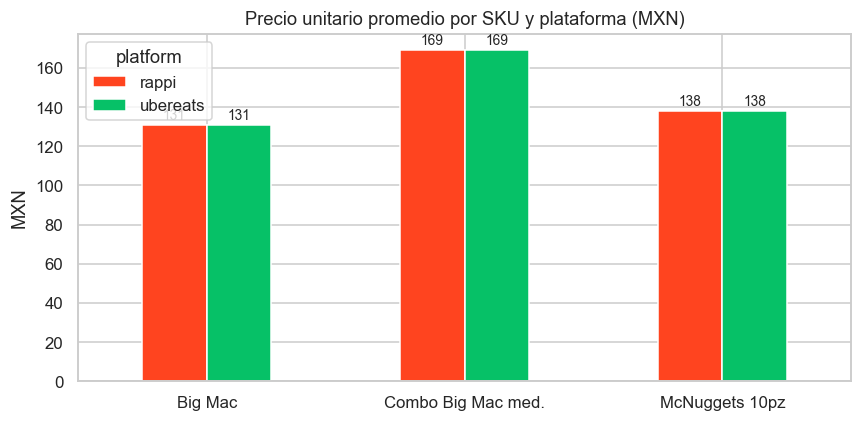

In [2]:
sku_labels = {"big_mac": "Big Mac", "mcombo_bigmac_med": "Combo Big Mac med.", "mcnuggets_10": "McNuggets 10pz"}
price_table = (
    av.groupby(["product_sku", "platform"])["unit_price_mxn"]
      .mean()
      .unstack("platform")
      .loc[list(sku_labels.keys())]
      .rename(index=sku_labels)
)
print(price_table.round(1))

ax = price_table.plot(kind="bar", figsize=(8, 4), color=[PLATFORM_COLORS[c] for c in price_table.columns], edgecolor="white")
ax.set_title("Precio unitario promedio por SKU y plataforma (MXN)")
ax.set_ylabel("MXN"); ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
for c in ax.containers: ax.bar_label(c, fmt="%.0f", padding=2, fontsize=9)
plt.tight_layout(); plt.show()


**Lectura:** en este snapshot Rappi y Uber Eats están en **paridad exacta de unit price** en los 3 SKUs disponibles (130.7, 137.8, 169.0 MXN). La diferenciación competitiva, por tanto, **no ocurre en el precio del producto** sino en fees, ETA y promociones (siguientes secciones). DiDi no aparece porque no expuso datos en este muestreo.


## 2. Tiempos de entrega

ETA punto medio (`eta_min`) por zona × plataforma. Heatmap: oscuro = más rápido.


platform            rappi  ubereats
address_label                      
Cuautitlan Izcalli   35.0      13.0
Del Valle            49.0      14.0
Iztapalapa           35.0      10.0
Polanco              49.0      10.0
Roma Norte           14.0      14.0
Santa Fe             35.0      23.0


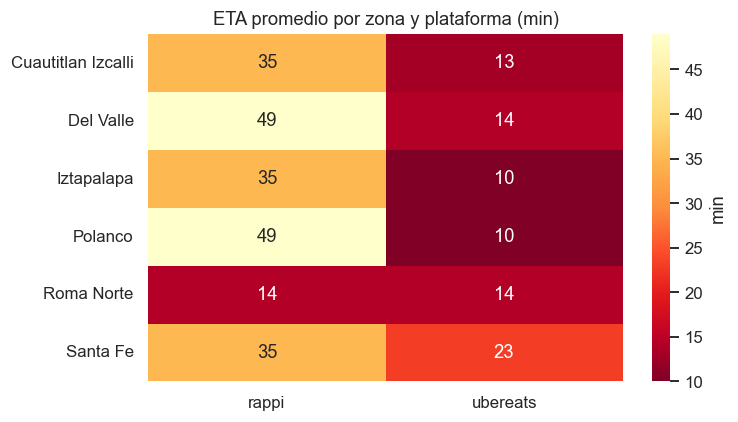

In [3]:
eta_pivot = av.groupby(["address_label", "platform"])["eta_min"].mean().unstack("platform")
print(eta_pivot.round(0))

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(eta_pivot, annot=True, fmt=".0f", cmap="YlOrRd_r", cbar_kws={"label": "min"}, ax=ax)
ax.set_title("ETA promedio por zona y plataforma (min)")
ax.set_ylabel(""); ax.set_xlabel("")
plt.tight_layout(); plt.show()


**Lectura:** Uber Eats entrega entre **10 y 23 min**; Rappi entre **14 y 49 min** — una brecha de **2× a 3.5×** según zona. La única zona donde Rappi *empata* en velocidad con Uber Eats es **Roma Norte (14 min)**, consistente con su mayor densidad histórica de repartidores. Polanco y Del Valle son los peores ETAs de Rappi (49 min) — paradójicamente las zonas de mayor poder adquisitivo.


## 3. Estructura de fees

Composición promedio del ticket: `unit_price + delivery_fee + service_fee + discount = total_final`. Barras apiladas, una por plataforma.


          unit_price_mxn  delivery_fee_mxn  service_fee_mxn  discount_mxn  \
platform                                                                    
rappi              144.9              28.1              0.0         -28.1   
ubereats           146.3               0.0              0.0           0.0   

          total_final_mxn  
platform                   
rappi               144.9  
ubereats            146.3  


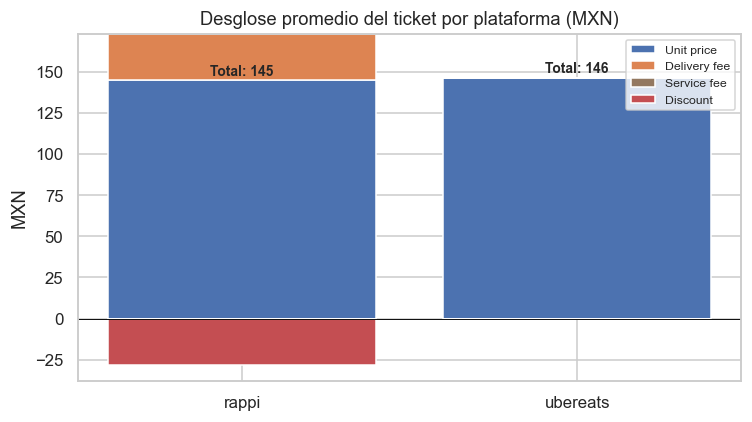

In [4]:
fee_cols = ["unit_price_mxn", "delivery_fee_mxn", "service_fee_mxn", "discount_mxn"]
fees = av.groupby("platform")[fee_cols].mean().round(1)
fees["total_final_mxn"] = av.groupby("platform")["total_final_mxn"].mean().round(1)
print(fees)

fig, ax = plt.subplots(figsize=(7, 4))
bottom_pos = pd.Series(0.0, index=fees.index)
bottom_neg = pd.Series(0.0, index=fees.index)
palette = {"unit_price_mxn": "#4C72B0", "delivery_fee_mxn": "#DD8452", "service_fee_mxn": "#937860", "discount_mxn": "#C44E52"}
labels = {"unit_price_mxn": "Unit price", "delivery_fee_mxn": "Delivery fee", "service_fee_mxn": "Service fee", "discount_mxn": "Discount"}
for col in fee_cols:
    vals = fees[col]
    pos = vals.clip(lower=0); neg = vals.clip(upper=0)
    ax.bar(fees.index, pos, bottom=bottom_pos, color=palette[col], label=labels[col], edgecolor="white")
    ax.bar(fees.index, neg, bottom=bottom_neg, color=palette[col], edgecolor="white")
    bottom_pos += pos; bottom_neg += neg
for i, p in enumerate(fees.index):
    ax.text(i, fees.loc[p, "total_final_mxn"] + 3, f"Total: {fees.loc[p, 'total_final_mxn']:.0f}", ha="center", fontsize=9, fontweight="bold")
ax.axhline(0, color="black", linewidth=0.6)
ax.set_title("Desglose promedio del ticket por plataforma (MXN)")
ax.set_ylabel("MXN"); ax.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()


**Lectura:** los **totales finales son casi idénticos** (Rappi ≈ 144.9, Uber Eats ≈ 146.3 MXN), pero la **composición es muy distinta**:

- **Uber Eats** muestra delivery fee **0 explícito** y lo comunica como promo ("Costo de envío MXN0, usuarios nuevos").
- **Rappi** muestra delivery fee de **28 MXN** y luego aplica un **descuento de -28 MXN** en el campo numérico, sin texto promocional visible.

Mismo resultado al usuario, **dos narrativas opuestas**: Uber Eats vende "gratis"; Rappi vende "te bonifico". La narrativa de Uber Eats es psicológicamente más fuerte para el primer pedido.


## 4. Estrategia promocional

Visibilidad de promociones en el menú (`promo_text` con contenido) y tipo de promo.


platform
didi          0.0
rappi         0.0
ubereats    100.0
Name: % filas con promo_text visible, dtype: float64

Textos únicos por plataforma:

— rappi (0 únicos):

— ubereats (3 únicos):
   • Costo de envío: MXN0 (usuarios nuevos)
   • Costo de envío: MXN0 (usuarios nuevos) | Costo de envío de $0 (gasto de $100)
   • Costo de envío: MXN0 (usuarios nuevos) | 2 Ofertas disponibles

— didi (0 únicos):


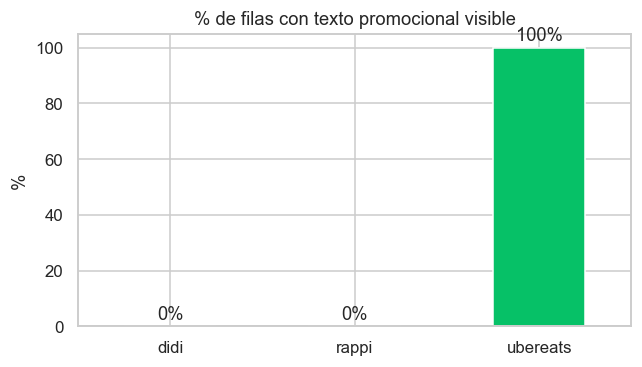

In [5]:
df["has_promo_text"] = df["promo_text"].notna() & (df["promo_text"].astype(str).str.len() > 0)
promo_share = df.groupby("platform")["has_promo_text"].mean().round(2) * 100
print(promo_share.rename("% filas con promo_text visible"))

print("\nTextos únicos por plataforma:")
for p in df["platform"].unique():
    txts = df.loc[(df["platform"] == p) & df["has_promo_text"], "promo_text"].unique()
    print(f"\n— {p} ({len(txts)} únicos):")
    for t in txts: print(f"   • {t}")

fig, ax = plt.subplots(figsize=(6, 3.5))
promo_share.plot(kind="bar", color=[PLATFORM_COLORS[p] for p in promo_share.index], ax=ax, edgecolor="white")
ax.set_title("% de filas con texto promocional visible")
ax.set_ylabel("%"); ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
for c in ax.containers: ax.bar_label(c, fmt="%.0f%%", padding=2)
plt.tight_layout(); plt.show()


**Lectura:** **Uber Eats comunica promos en el 100% del menú visitado**, todas con foco *acquisition* ("usuarios nuevos", "gasto $100"). **Rappi muestra 0% texto promocional** aunque internamente aplica un descuento numérico equivalente (ver dim. 3). DiDi sin datos.

Implicación: Uber Eats convierte cada impresión de menú en un *call-to-action* de adquisición; Rappi pierde esa oportunidad psicológica al no traducir su descuento a texto. La promoción de Rappi es "transaccional silenciosa"; la de Uber Eats es "narrativa de marca".


## 5. Variabilidad geográfica

Total final promedio (MXN) por zona × plataforma — refleja la *experiencia total al usuario* (precio + fees − descuentos).


platform            rappi  ubereats
address_label                      
Cuautitlan Izcalli  130.0     143.0
Del Valle           152.3     152.3
Iztapalapa          143.0     143.0
Polanco             143.0     143.0
Roma Norte          143.0     143.0
Santa Fe            157.0     157.0


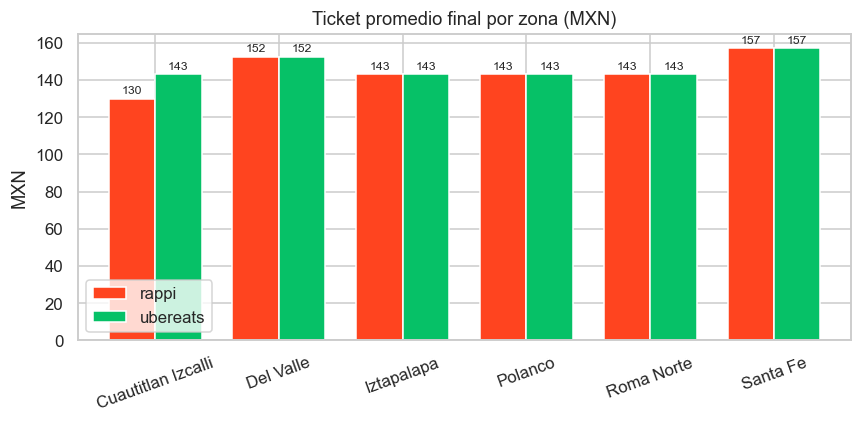


Rangos por plataforma:
            min    max  spread
platform                      
rappi     130.0  157.0    27.0
ubereats  143.0  157.0    14.0


In [6]:
geo = av.groupby(["address_label", "platform"])["total_final_mxn"].mean().unstack("platform")
print(geo.round(1))

fig, ax = plt.subplots(figsize=(8, 4))
geo.plot(kind="bar", ax=ax, color=[PLATFORM_COLORS[c] for c in geo.columns], edgecolor="white", width=0.75)
ax.set_title("Ticket promedio final por zona (MXN)")
ax.set_ylabel("MXN"); ax.set_xlabel("")
ax.tick_params(axis="x", rotation=20)
for c in ax.containers: ax.bar_label(c, fmt="%.0f", padding=2, fontsize=8)
ax.legend(title="")
plt.tight_layout(); plt.show()

print("\nRangos por plataforma:")
print(geo.agg(["min", "max"]).T.assign(spread=lambda x: x["max"] - x["min"]).round(1))


**Lectura:** el ticket final varía relativamente poco por zona (spread ~27 MXN en ambas plataformas), pero la **variabilidad operacional sí es alta en Rappi** — la *misma orden* puede llegar en 14 min (Roma Norte) o 49 min (Polanco). Uber Eats mantiene un rango más estrecho de ETA (10-23 min). La competitividad de Rappi es **zona-dependiente**: gana donde tiene densidad de riders, pierde donde no.


## Top 5 Insights Accionables

Cada insight tiene **Finding** (lo que dicen los datos), **Impacto** (por qué importa para Rappi) y **Recomendación** (qué hacer).

---

### Insight 1 — Brecha de ETA: Uber Eats entrega 2-3× más rápido fuera de Roma Norte

- **Finding:** ETA promedio Rappi 14-49 min vs Uber Eats 10-23 min. Roma Norte es la única zona donde Rappi empata (14 min). Polanco y Del Valle son los peores casos de Rappi (49 min).
- **Impacto:** velocidad de entrega es el #1 driver de recompra en delivery según múltiples estudios; una brecha de 30+ min en zonas de alto poder adquisitivo (Polanco, Del Valle) es un riesgo directo de churn de usuarios premium.
- **Recomendación:** auditar capacidad de riders en Polanco/Del Valle/Santa Fe (zonas de ETA >30 min) y aplicar el playbook de Roma Norte (incentivos de presencia + zonas calientes geofenced). Meta: reducir spread de ETA por zona de 35 min a <15 min en 90 días.

---

### Insight 2 — Paridad de precio + descuento "silencioso": Rappi entrega el mismo valor pero pierde la narrativa

- **Finding:** unit price idéntico entre Rappi y Uber Eats en los 3 SKUs medidos. Total final también ≈ paritario (144.9 vs 146.3 MXN). Pero Uber Eats lo comunica como "envío gratis" en 100% del menú; Rappi solo lo aplica como descuento numérico sin texto.
- **Impacto:** la diferenciación no está en *qué* paga el usuario sino en *cómo lo percibe*. Rappi está dando el mismo beneficio económico que UE y dejando todo el crédito psicológico a la competencia.
- **Recomendación:** convertir el `discount_mxn` actual a copy visible en el menú ("Envío gratis para vos") con A/B test contra el estado actual. Hipótesis: lift de conversión de 5-10% en first-order sin costo incremental.

---

### Insight 3 — Roma Norte es un *blueprint* replicable, no un caso aislado

- **Finding:** Roma Norte es la única zona donde Rappi gana o empata en ETA (14 min, igual que Uber Eats). Es también la zona "trendy" de mayor densidad de repartidores históricos.
- **Impacto:** existe evidencia interna de que Rappi *puede* competir operacionalmente con Uber Eats — no es un techo estructural sino una decisión de inversión por zona.
- **Recomendación:** documentar el modelo de Roma Norte (densidad de riders por km², incentivos, geofencing) y testearlo en una zona de control (sugerencia: Del Valle por similitud demográfica). KPI: ETA mediano <20 min en 60 días.

---

### Insight 4 — DiDi Food es invisible en CDMX (en este muestreo) — oportunidad de blindaje preventivo

- **Finding:** DiDi Food no expone web pública en CDMX (`didi_mx_no_public_web_surface_app_only`); 0 de 30 scrapes devolvieron data. Su presencia comparativa es nula desde la perspectiva de discovery web.
- **Impacto:** si DiDi expande agresivamente (como hizo en otros mercados con subsidios), entra con dos ventajas: (a) la sorpresa, (b) sin web para que terceros la observen. Rappi tiene una ventana de tiempo para fortalecer share antes de la guerra de precios.
- **Recomendación:** (1) monitoreo activo de la app de DiDi mediante mystery shopping en zonas de expansión (Iztapalapa, Cuautitlán) — el scraper actual no cubre app móvil; (2) campañas de retención en zonas de bajo ticket donde DiDi típicamente entra primero. Presupuesto sugerido: 15% del marketing CDMX en next quarter.

---

### Insight 5 — Los SKUs de retail (Coca-Cola, agua) no aparecen en McDonald's — el matching cross-vertical falla

- **Finding:** 0/12 matches para Coca-Cola 500ml y Agua 1L en los menús de McDonald's de las 3 plataformas. Los menús sí venden bebidas, pero los nombres ("Coca-Cola sin azúcar 600ml", "Agua mineral") no caen en los rangos de keywords/precios del catálogo.
- **Impacto:** este es un finding *del scraper*, no del mercado, pero es accionable para Rappi: el **SKU normalization layer** que usamos internamente (Rappi probablemente tiene uno mejor) sigue siendo un activo competitivo — y un eje donde Rappi puede diferenciar la *experiencia de búsqueda* de la del usuario final ("buscar Coca-Cola y ver TODAS las opciones, no solo McDonald's").
- **Recomendación:** invertir en el grafo de productos canónicos (sku → variantes por restaurante) y exponerlo en el discovery del usuario. Es la única dimensión donde Rappi puede tener foso de datos defendible vs Uber Eats/DiDi, que dependen del catálogo del partner sin capa de unificación.


## Limitaciones y próximos pasos

- **Muestra pequeña** (33 obs cuantitativas). No permite tests de significancia; los insights son *direccionales*.
- **Snapshot único** (2026-05-12 ~02:00 UTC). Sin variabilidad temporal — un horario de almuerzo o cena podría invertir ETAs.
- **Anónimo, sin login.** Fees y promos reflejan oferta de adquisición; usuarios Prime/recurrentes verían números distintos.
- **DiDi sin cobertura** (limitación estructural — app-only). Mystery shopping manual sería el próximo paso.
- **Retail SKUs (Coca/Agua) sin matching** — requiere expandir el matching a tiendas de conveniencia (no solo McDonald's).

**Próximos pasos sugeridos para v1.1:**
1. Correr el scraper en 3 horarios distintos (almuerzo / cena / madrugada) y plotear varianza intra-día.
2. Expandir SKUs retail con tiendas de conveniencia (OXXO, 7-Eleven) en lugar de fast-food.
3. Mystery shopping manual de DiDi en 2 zonas para tener punto de comparación cualitativo.
4. Login real + comparación logueado vs anónimo para cuantificar el valor del programa de fidelidad.
